
# Lab: Tokenization and Embeddings in LLMs
### Beginner-friendly Jupyter Notebook

This notebook introduces two core ideas used in Large Language Models (LLMs):

- **Tokenization**
- **Embeddings**

We will first build the concepts step by step, and then run simple Python examples.

---

## Learning goals

By the end of this notebook, you should be able to:

- understand what tokenization is
- understand why LLMs use token IDs
- understand what embeddings are
- see how text becomes vectors
- generate token and sentence embeddings in Python
- compare meanings using cosine similarity


## **Tokens: The Currency of LLMs** ##

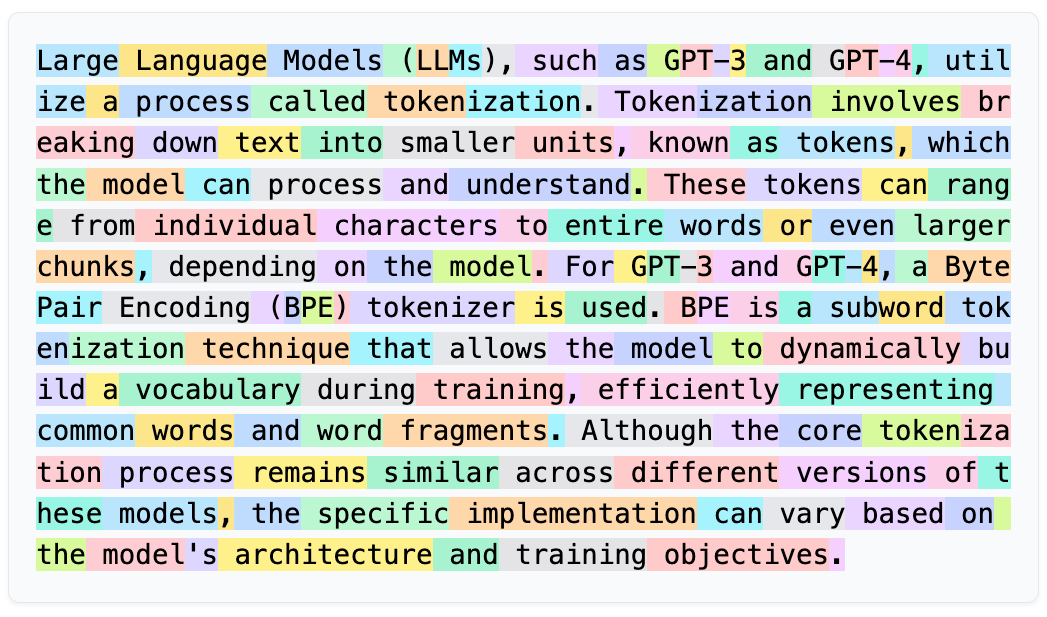

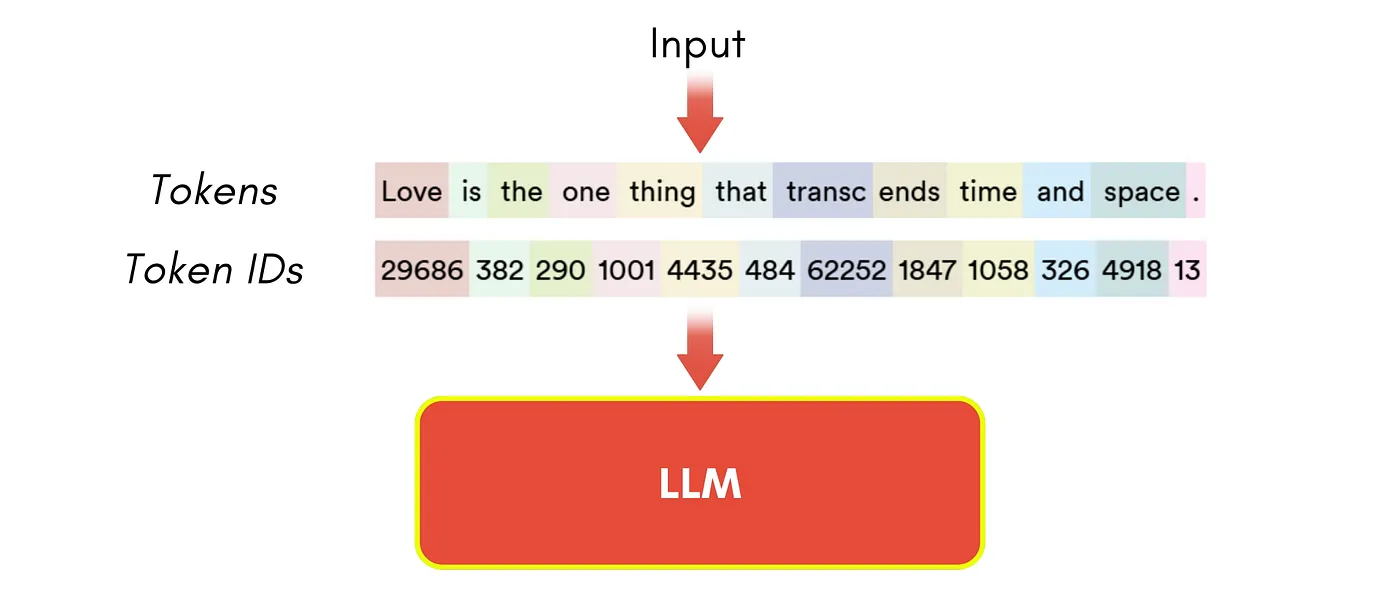

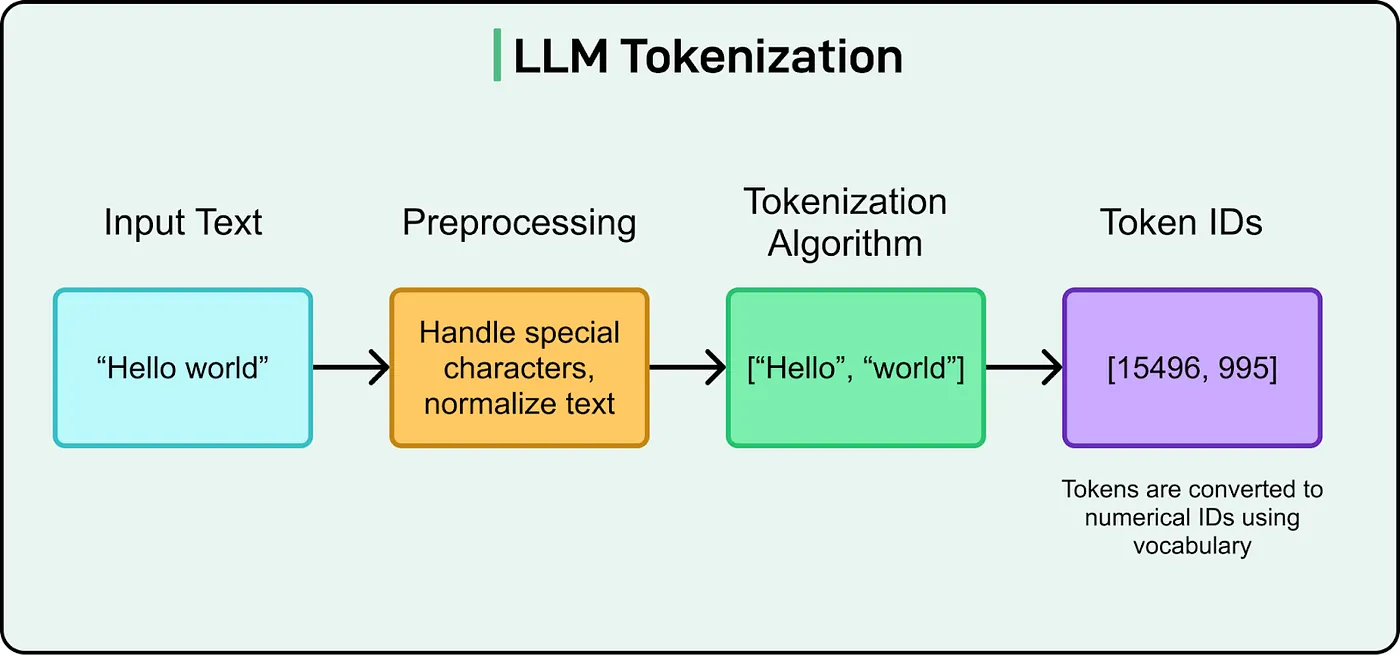


## 1. What is tokenization?

A language model cannot directly read raw text like humans do.

So the first step is to **break text into smaller units**, called **tokens**.

### Example

Sentence:

`I love learning AI`

Possible tokens:

- `I`
- `love`
- `learning`
- `AI`

But modern LLMs often do **subword tokenization**, which means they may split words into smaller meaningful pieces.

Example:

- `unhappiness` → `un`, `happi`, `ness`

This helps the model handle rare words, new words, and spelling variations more efficiently.

---

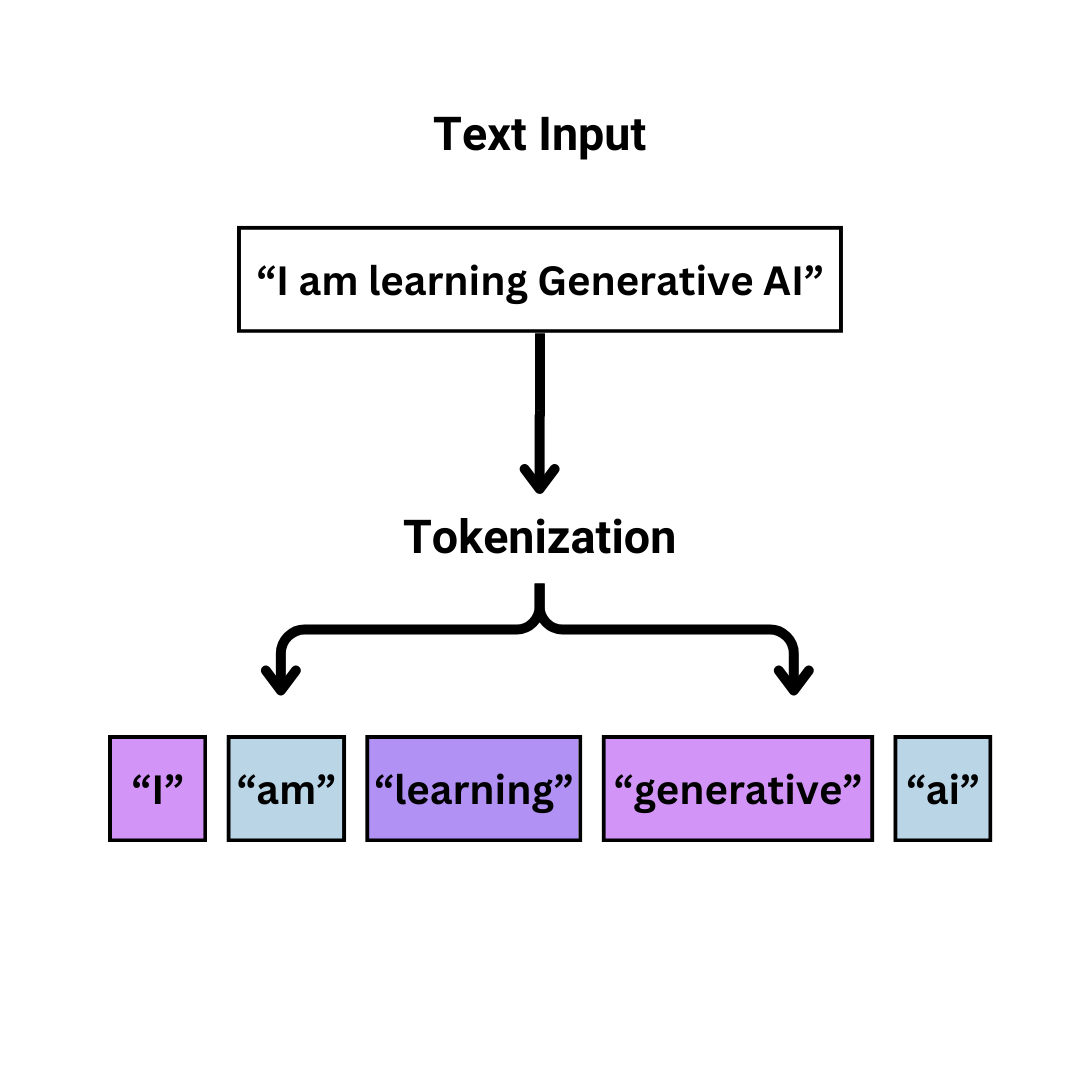



## 2. Why do we need tokenization?

Because neural networks work with **numbers**, not text.

So the pipeline looks like this:

**Text → Tokens → Token IDs → Embeddings → Model**



## 3. What is a token ID?

A token ID is simply the numeric index of a token in the model vocabulary.

Example:

- `"hello"` → `7592`
- `"world"` → `2088`

These IDs do **not** contain meaning by themselves.  
They are just lookup keys.

---



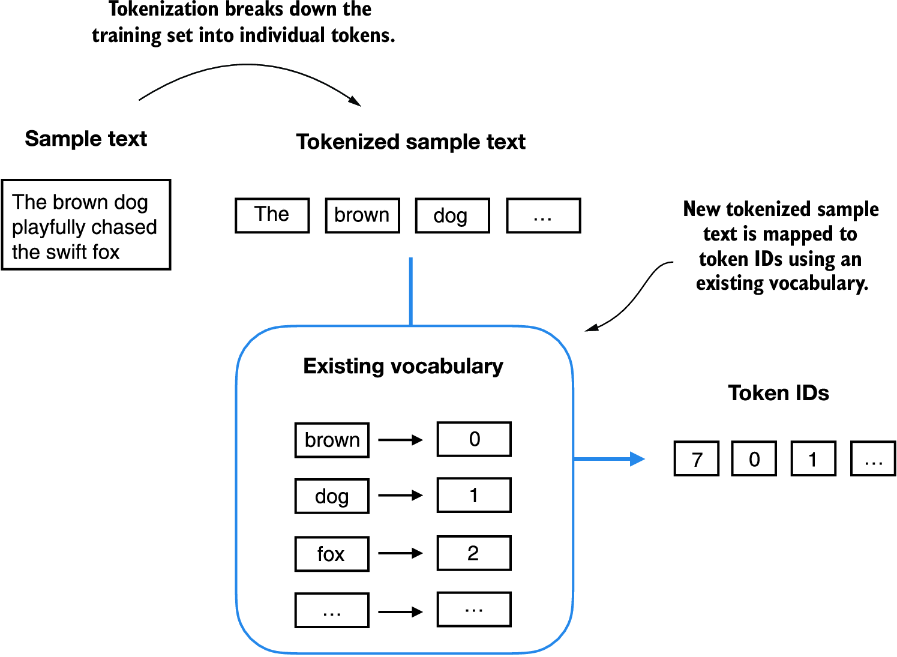

## 4. What is an embedding?

An embedding is a dense numerical vector that represents a token or sentence.

Example:

- `"cat"` → `[0.12, -0.44, 0.91, ...]`
- `"dog"` → `[0.10, -0.40, 0.87, ...]`

Words with similar meanings often have similar vectors.

So embeddings help the model learn **semantic meaning**.

---

## 5. Token ID vs Embedding

### Token ID
A simple integer:
- `"cat"` → `4937`

### Embedding
A learned vector:
- `4937` → `[0.12, -0.44, 0.91, ...]`

So:

- **token ID** = vocabulary index
- **embedding** = learned meaning representation


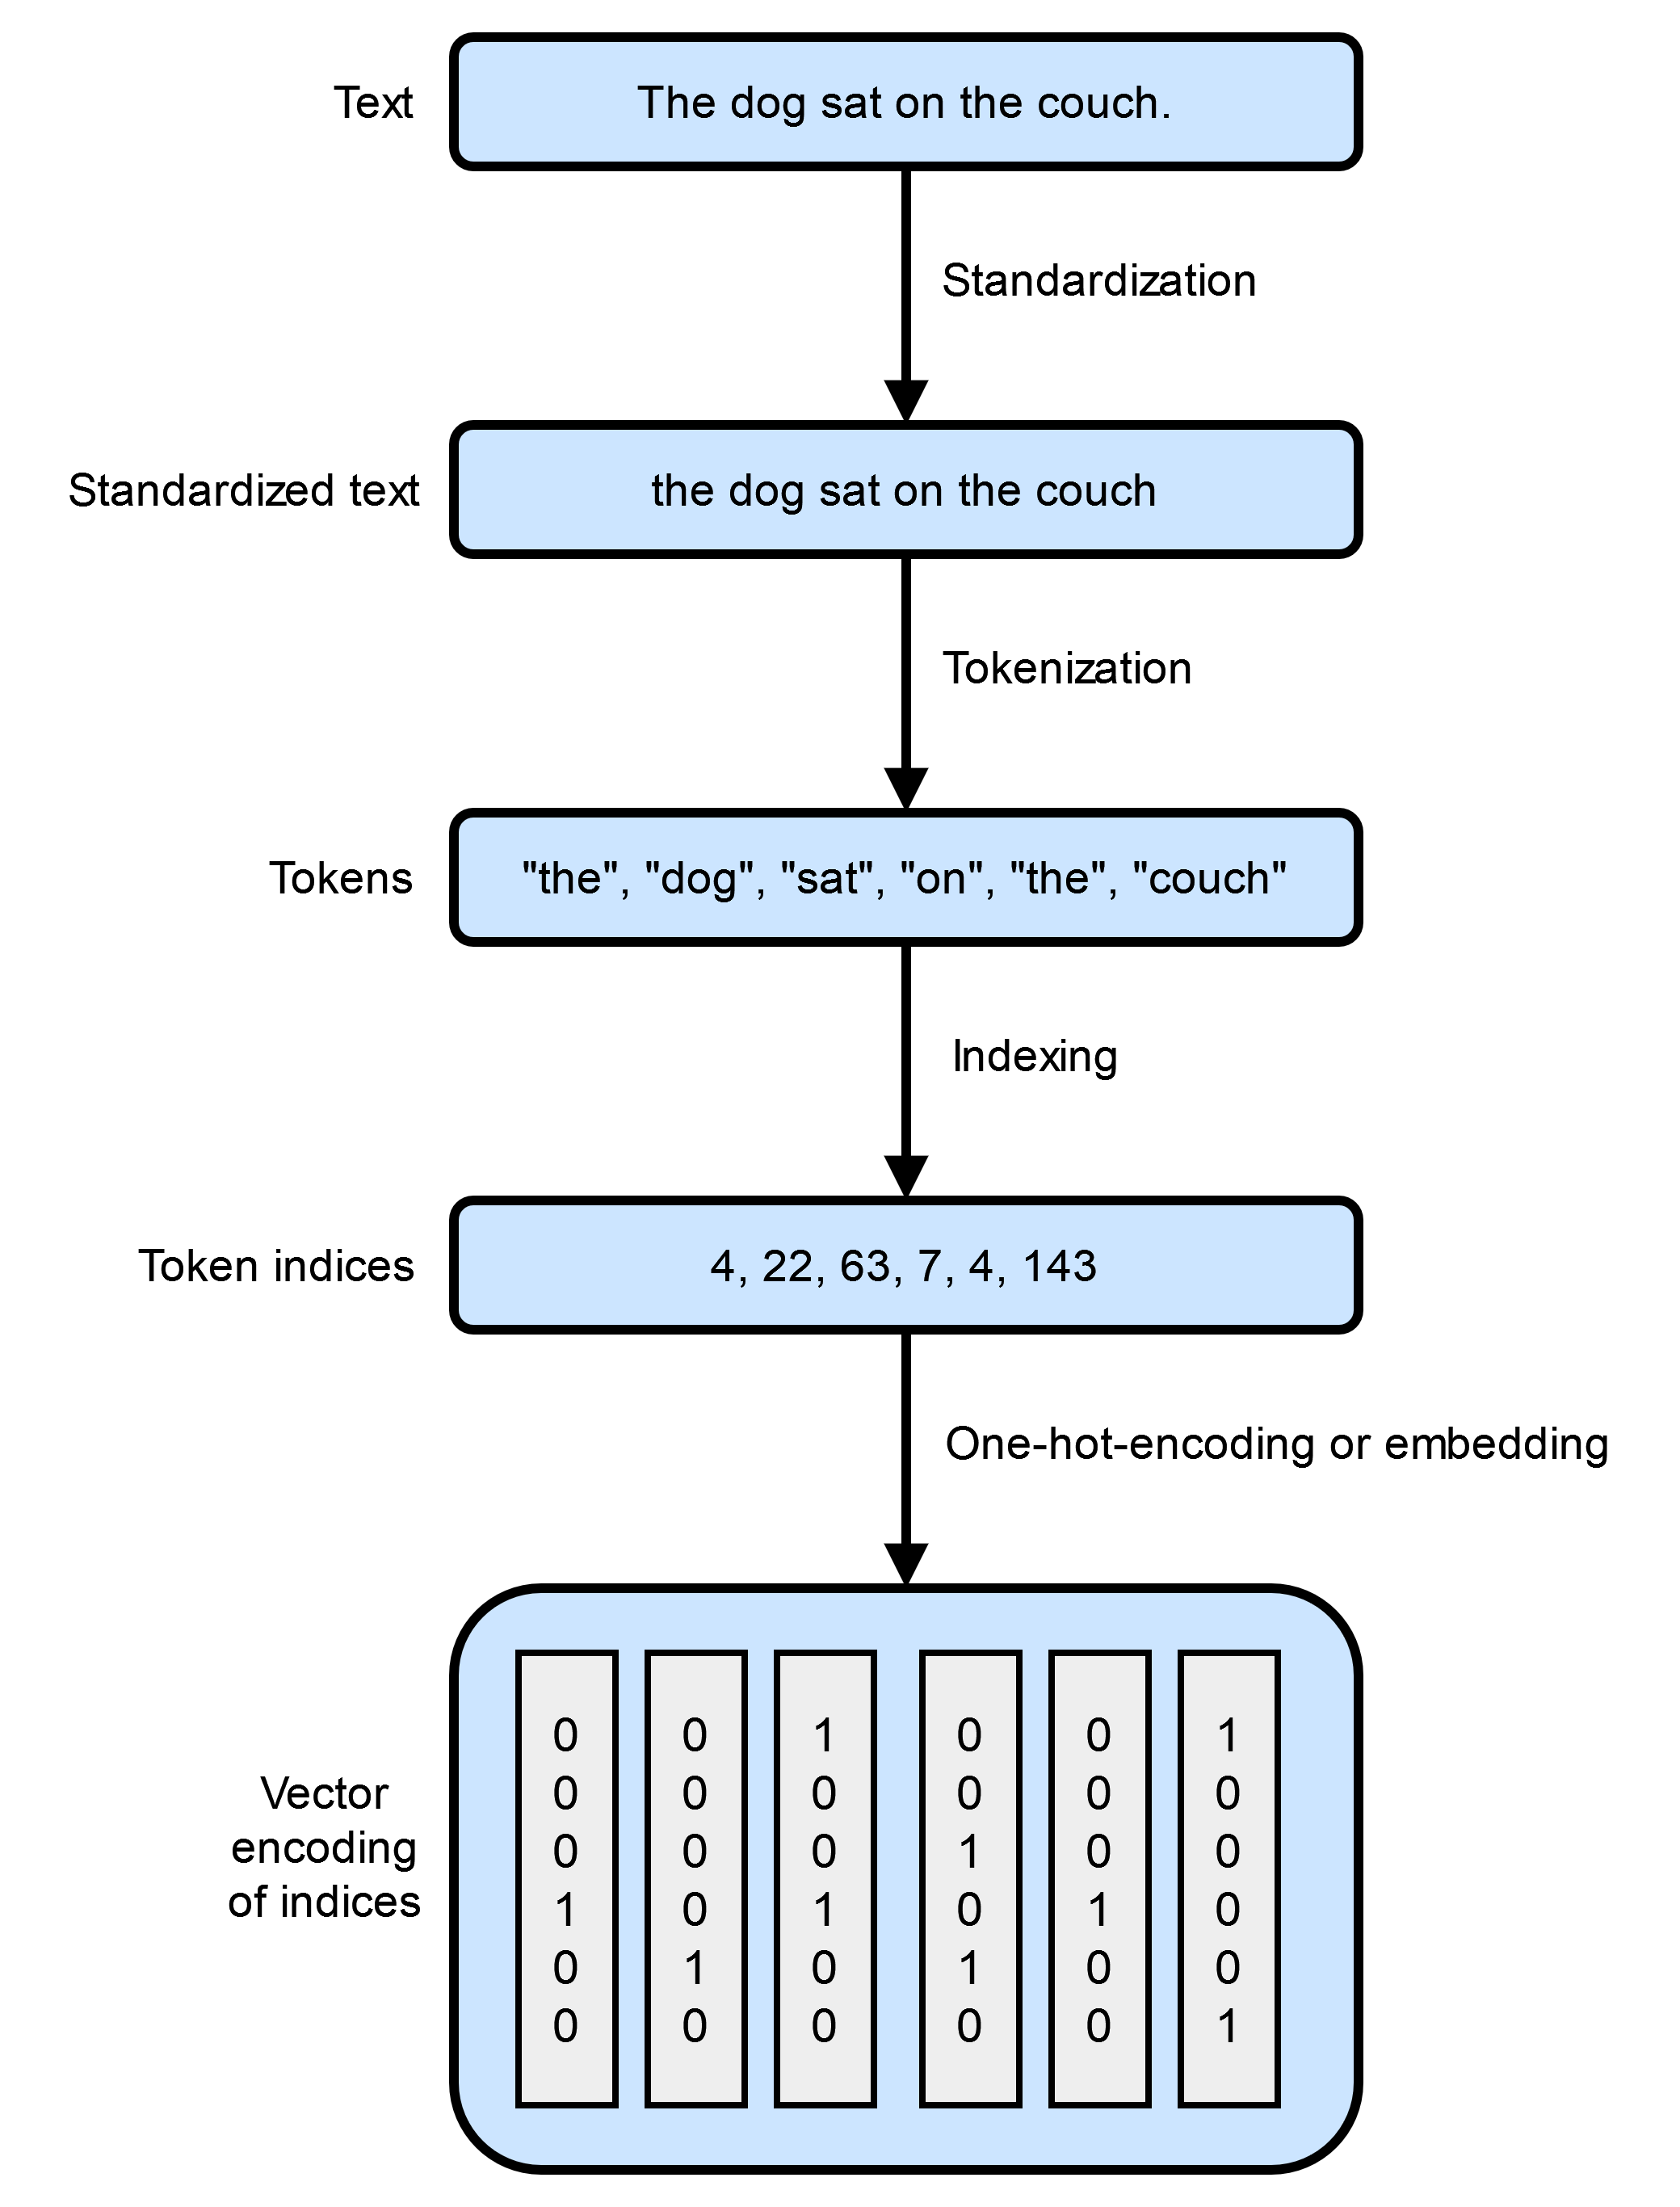

https://livebook.manning.com/wiki/categories/llm/token+id


## 6. Types of tokenization

### Word tokenization
Splits by words.

Example:
`I love AI` → `["I", "love", "AI"]`

### Character tokenization
Splits by characters.

Example:
`cat` → `["c", "a", "t"]`

### Subword tokenization
Splits into smaller useful parts.

Example:
`unbelievable` → `["un", "believ", "able"]`

Modern LLMs mostly use **subword tokenization** because it balances vocabulary size and flexibility.


https://tiktokenizer.vercel.app/


## 7. Install required libraries

Run this cell once if the libraries are not installed in your notebook environment.


In [ ]:

# Uncomment and run if needed
# !pip install transformers sentence-transformers scikit-learn matplotlib torch



## 8. Basic tokenization using plain Python

Before using LLM tokenizers, let us start with the simplest idea: splitting a sentence into words.


In [ ]:

text = "I love learning about large language models."

tokens = text.split()

print("Original text:", text)
print("Tokens:", tokens)
print("Number of tokens:", len(tokens))


Original text: I love learning about large language models.
Tokens: ['I', 'love', 'learning', 'about', 'large', 'language', 'models.']
Number of tokens: 7



### Explanation

`split()` breaks text on spaces.

This is easy to understand, but real LLM tokenizers are smarter because they:

- handle punctuation
- add special tokens
- split rare words into subwords
- map tokens to IDs



## 9. Using a real tokenizer from Hugging Face

Now let us use a pretrained tokenizer from BERT.


In [ ]:

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

text = "I love learning about large language models."
encoded = tokenizer(text)

print("Input text:", text)
print("\nToken IDs:", encoded["input_ids"])
print("\nTokens:", tokenizer.convert_ids_to_tokens(encoded["input_ids"]))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Input text: I love learning about large language models.

Token IDs: [101, 1045, 2293, 4083, 2055, 2312, 2653, 4275, 1012, 102]

Tokens: ['[CLS]', 'i', 'love', 'learning', 'about', 'large', 'language', 'models', '.', '[SEP]']



### What happened here?

The tokenizer did several things:

1. split the text into tokens
2. converted tokens into token IDs
3. added special tokens

You may see tokens like:

- `[CLS]` → special start token
- `[SEP]` → separator/end token

These are commonly used in BERT-style models.



## 10. Subword tokenization example

Now let us see how complex words are split.


In [ ]:

words = ["playing", "unhappiness", "transformers", "tokenization", "embedding"]

for word in words:
    print(word, "->", tokenizer.tokenize(word))


playing -> ['playing']
unhappiness -> ['un', '##ha', '##pp', '##iness']
transformers -> ['transformers']
tokenization -> ['token', '##ization']
embedding -> ['em', '##bed', '##ding']



### Explanation

In BERT tokenization, you may see pieces like `##ing` or `##tion`.

The `##` means the token continues from the previous part.

Example:

- `playing` → `play`, `##ing`

This helps the model represent many words without storing every full word separately.



## 11. Convert tokens into IDs

Let us look at token strings and their numeric IDs side by side.


In [ ]:

text = "Tokenization is the first step in NLP."

tokens = tokenizer.tokenize(text)
token_ids = tokenizer.convert_tokens_to_ids(tokens)

print("Tokens:", tokens)
print("Token IDs:", token_ids)


Tokens: ['token', '##ization', 'is', 'the', 'first', 'step', 'in', 'nl', '##p', '.']
Token IDs: [19204, 3989, 2003, 1996, 2034, 3357, 1999, 17953, 2361, 1012]



### Key idea

Every token has an ID in the vocabulary.

That ID is later used to fetch the token's embedding from the embedding matrix.



## 12. Padding and attention mask

When we process multiple sentences together, they may have different lengths.

But tensors in deep learning need consistent shape.

So we use:

- **padding** to make all sequences the same length
- **attention mask** to tell the model which tokens are real


In [ ]:

sentences = [
    "I love AI.",
    "Transformers are powerful models for language understanding."
]

encoded_batch = tokenizer(
    sentences,
    padding=True,
    truncation=True,
    return_tensors="pt"
)

print("Input IDs:\n", encoded_batch["input_ids"])
print("\nAttention Mask:\n", encoded_batch["attention_mask"])


Input IDs:
 tensor([[  101,  1045,  2293,  9932,  1012,   102,     0,     0,     0,     0],
        [  101, 19081,  2024,  3928,  4275,  2005,  2653,  4824,  1012,   102]])

Attention Mask:
 tensor([[1, 1, 1, 1, 1, 1, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])



### Explanation

In the attention mask:

- `1` means real token
- `0` means padding token

This prevents the model from paying attention to artificial padding.



## 13. What is an embedding matrix?

Suppose:

- vocabulary size = 10
- embedding dimension = 4

Then the embedding layer stores a matrix of shape:

**10 × 4**

That means:

- 10 rows → one row for each token
- 4 columns → 4 values representing that token

When a token ID comes in, the model looks up the corresponding row.


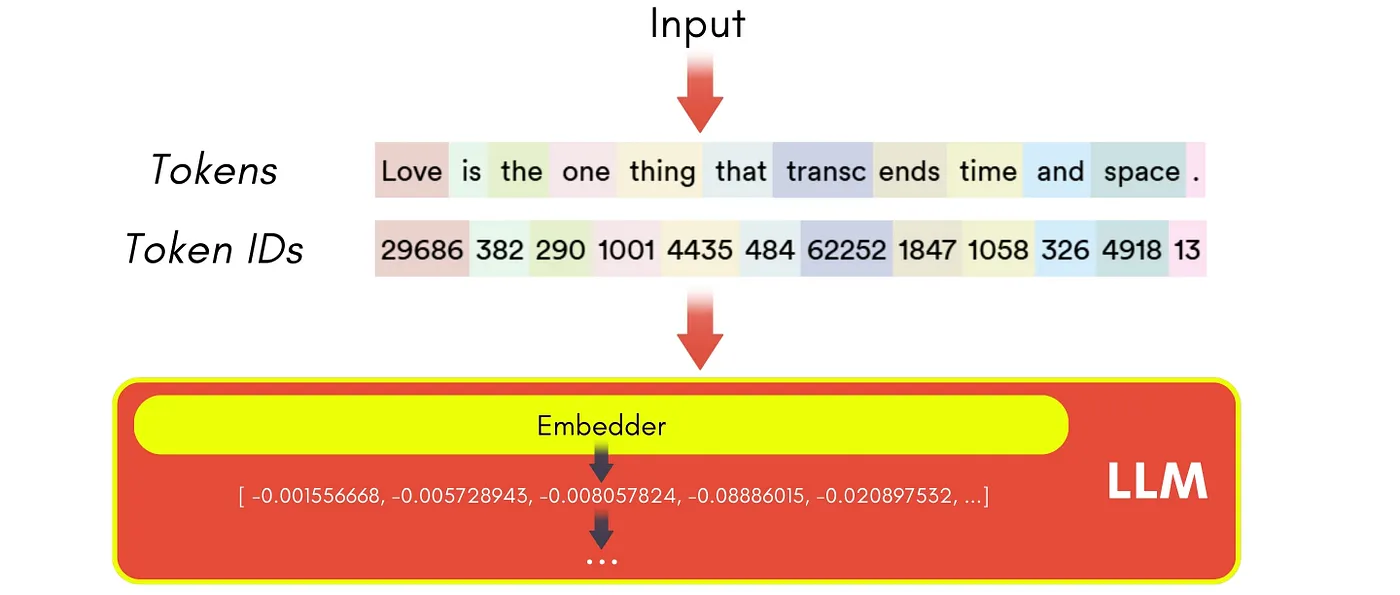

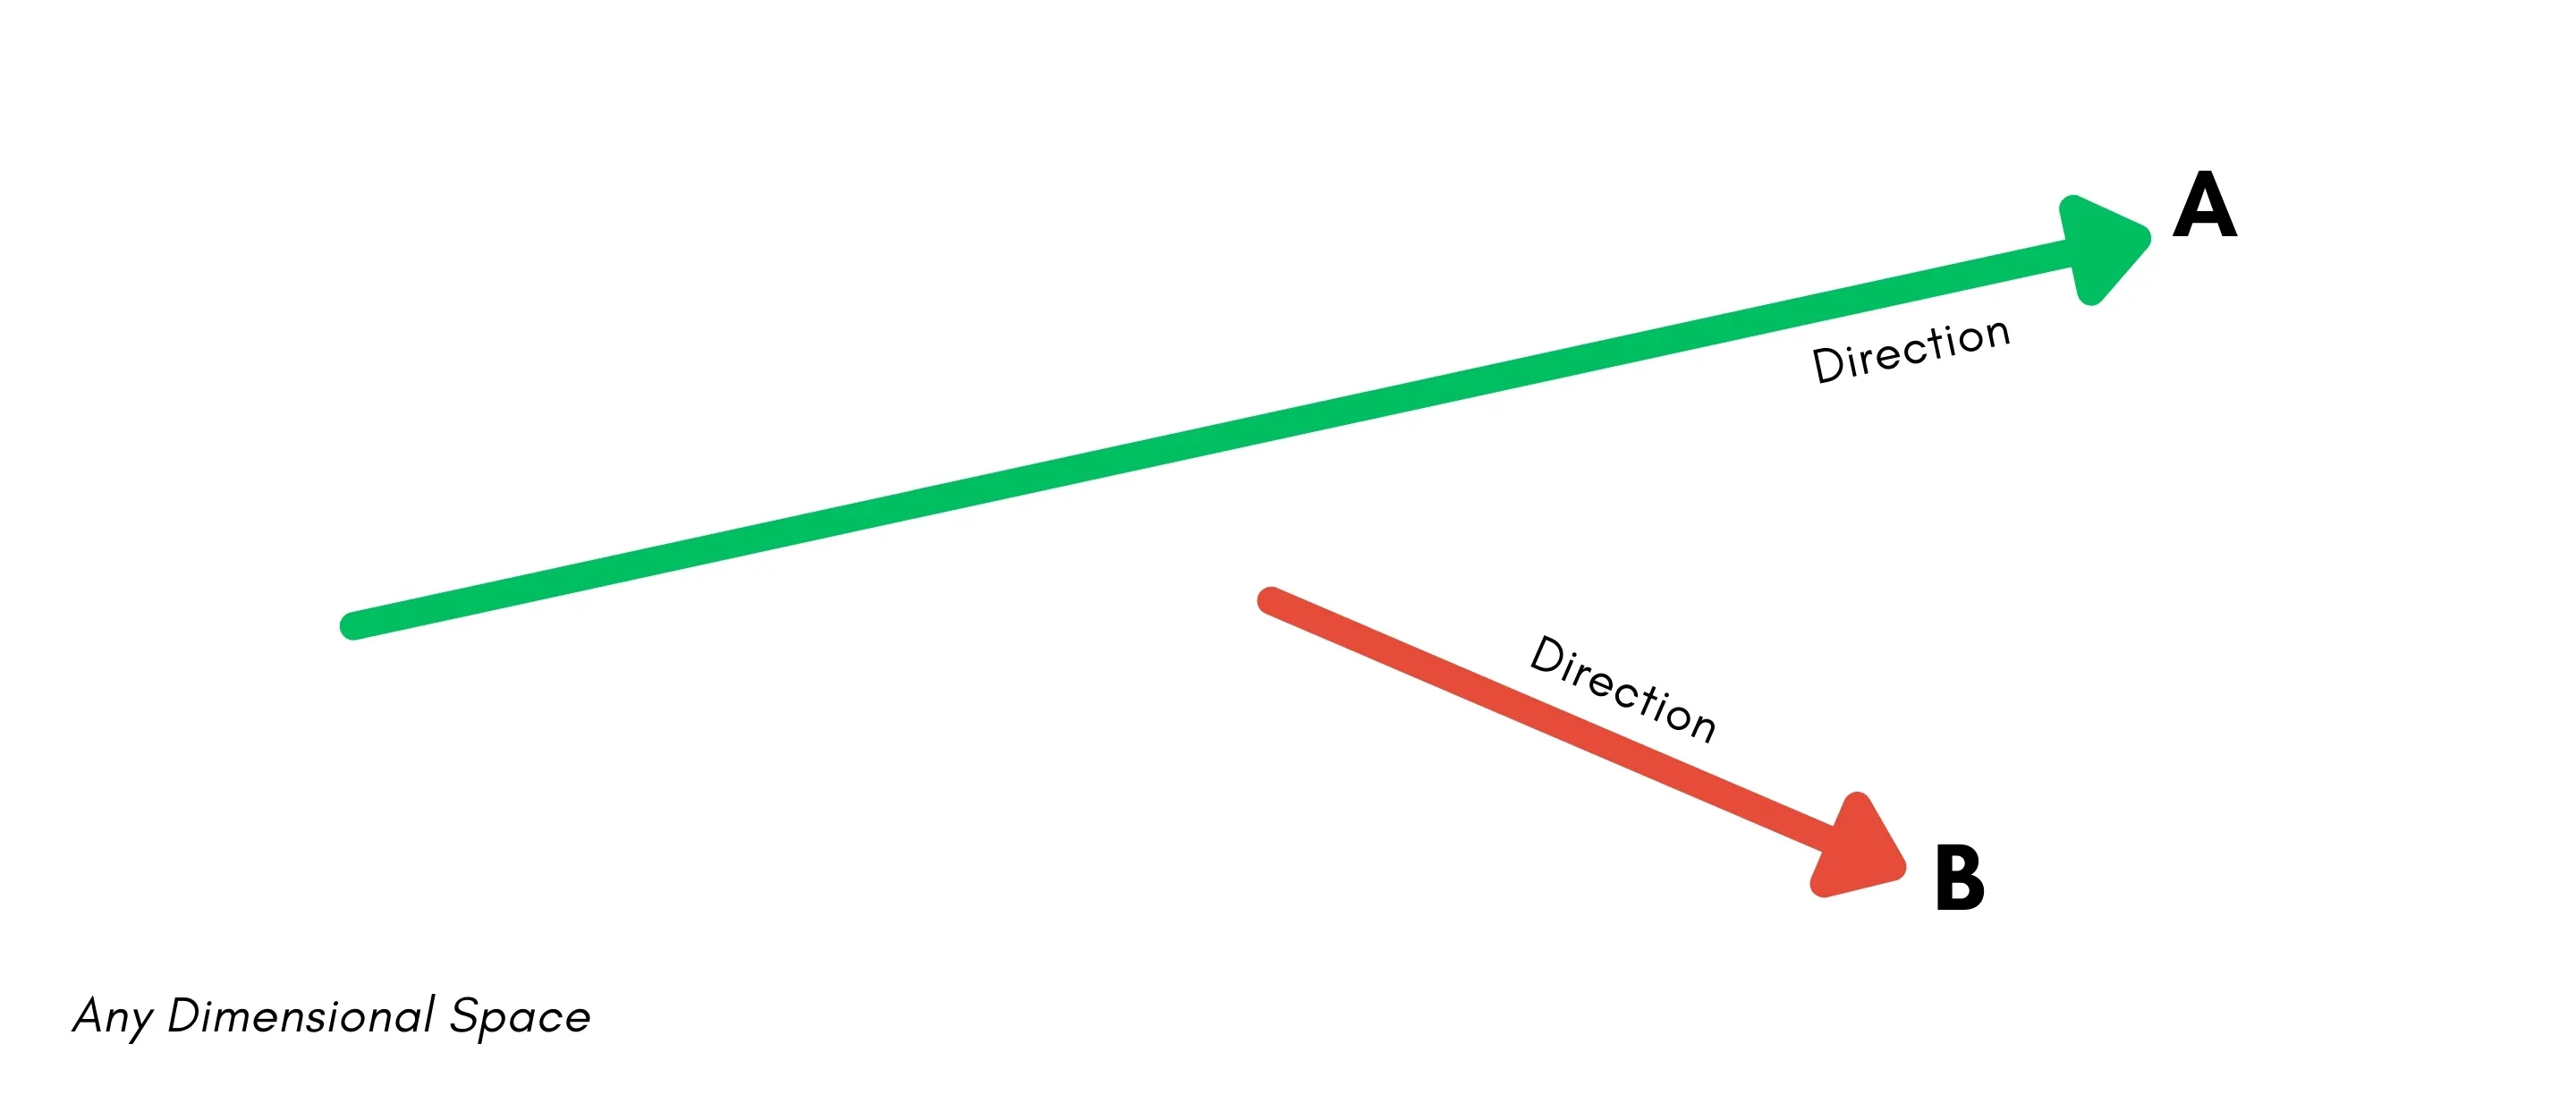


## 14. Simple embedding lookup using PyTorch

This example shows the basic idea behind embeddings.


In [ ]:

import torch
import torch.nn as nn

vocab_size = 10
embedding_dim = 4

embedding_layer = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embedding_dim)

token_ids = torch.tensor([1, 3, 5, 7])

embeddings = embedding_layer(token_ids)

print("Token IDs:", token_ids)
print("\nEmbeddings shape:", embeddings.shape)
print("\nEmbeddings:\n", embeddings)


Token IDs: tensor([1, 3, 5, 7])

Embeddings shape: torch.Size([4, 4])

Embeddings:
 tensor([[-0.3021,  0.2353, -1.6699, -0.1169],
        [-0.8770,  1.2722, -0.5542,  0.6597],
        [-0.6696,  0.7253,  0.3768,  0.1780],
        [-0.3712, -0.6852,  0.5714,  1.7359]], grad_fn=<EmbeddingBackward0>)



### Syntax explanation

`nn.Embedding(num_embeddings, embedding_dim)`

- `num_embeddings` = vocabulary size
- `embedding_dim` = vector size for each token

If the input token IDs are:

`[1, 3, 5, 7]`

the embedding layer returns 4 vectors, one for each token ID.



## 15. Token embeddings from a pretrained transformer

Now let us use a real model and extract token-level embeddings.


In [ ]:

from transformers import AutoModel

model = AutoModel.from_pretrained("bert-base-uncased")

text = "I love learning about transformers."
inputs = tokenizer(text, return_tensors="pt")

outputs = model(**inputs)
last_hidden_state = outputs.last_hidden_state

print("Input IDs shape:", inputs["input_ids"].shape)
print("Last hidden state shape:", last_hidden_state.shape)


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Input IDs shape: torch.Size([1, 8])
Last hidden state shape: torch.Size([1, 8, 768])



### What does this shape mean?

If the output shape is:

`(1, 8, 768)`

it means:

- `1` sentence in the batch
- `8` tokens in the sequence
- `768` values for each token representation

These are **contextual embeddings** because each token vector depends on the surrounding words.



## 16. View token-level embeddings

Let us print each token and the first few values of its embedding.


In [ ]:

tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
embeddings = last_hidden_state[0]

for token, embedding in zip(tokens, embeddings):
    print(f"Token: {token}")
    print("First 5 embedding values:", embedding[:5].detach().numpy())
    print("-" * 50)


Token: [CLS]
First 5 embedding values: [ 0.08897816  0.08220187 -0.04381446 -0.34592968 -0.31234866]
--------------------------------------------------
Token: i
First 5 embedding values: [ 0.55341226 -0.10553931 -0.26924157 -0.1432773   0.13796578]
--------------------------------------------------
Token: love
First 5 embedding values: [0.6680308  0.9227092  0.5274659  0.15472211 0.48028883]
--------------------------------------------------
Token: learning
First 5 embedding values: [-0.097132    0.47175568  0.30414757  0.4747793   0.4703309 ]
--------------------------------------------------
Token: about
First 5 embedding values: [0.7694936  0.5432123  0.00830137 0.35196477 0.9493021 ]
--------------------------------------------------
Token: transformers
First 5 embedding values: [ 2.1631398   0.05025787 -0.0696102   0.11340986  0.9043477 ]
--------------------------------------------------
Token: .
First 5 embedding values: [ 0.616762    0.08599985 -0.15752107  0.18493122  0.050719


### Important concept

These embeddings are not just fixed dictionary values.

They depend on context.

So the same word may have different embeddings in different sentences.



## 17. Contextual meaning example

Consider the word **bank**.

It can mean:

- river bank
- financial bank

A contextual model like BERT can represent these differently depending on the sentence.


In [ ]:

sent1 = "He sat on the bank of the river."
sent2 = "She went to the bank to deposit money."

for text in [sent1, sent2]:
    inputs = tokenizer(text, return_tensors="pt")
    outputs = model(**inputs)
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    print("\nSentence:", text)
    print("Tokens:", tokens)



Sentence: He sat on the bank of the river.
Tokens: ['[CLS]', 'he', 'sat', 'on', 'the', 'bank', 'of', 'the', 'river', '.', '[SEP]']

Sentence: She went to the bank to deposit money.
Tokens: ['[CLS]', 'she', 'went', 'to', 'the', 'bank', 'to', 'deposit', 'money', '.', '[SEP]']



### Why this matters

Older embedding methods like Word2Vec usually gave one fixed vector per word.

Modern transformer models create **context-aware embeddings**, which is much more powerful.



## 18. Sentence embeddings

Sometimes we want one vector for the whole sentence instead of one vector per token.

This is useful in:

- semantic search
- clustering
- retrieval systems
- recommendation systems
- RAG pipelines


In [ ]:

from sentence_transformers import SentenceTransformer

sentence_model = SentenceTransformer("all-MiniLM-L6-v2")

sentences = [
    "I love machine learning.",
    "Artificial intelligence is fascinating.",
    "The weather is very hot today."
]

sentence_embeddings = sentence_model.encode(sentences)

print("Embedding shape:", sentence_embeddings.shape)
print("\nFirst sentence embedding (first 10 values):")
print(sentence_embeddings[0][:10])


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding shape: (3, 384)

First sentence embedding (first 10 values):
[-0.01685111 -0.07072178  0.08554105 -0.00176612  0.04520883 -0.05311213
 -0.04855525 -0.03103911  0.01999198  0.00137788]



### Explanation

If the output shape is something like:

`(3, 384)`

it means:

- 3 sentences
- each sentence converted into a 384-dimensional vector



## 19. Measure similarity between sentence embeddings

We can compare sentence meanings using **cosine similarity**.

Higher similarity means the vectors point in similar directions.


In [ ]:

from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

similarity_matrix = cosine_similarity(sentence_embeddings)

similarity_df = pd.DataFrame(similarity_matrix, index=sentences, columns=sentences)
similarity_df


,I love machine learning.,Artificial intelligence is fascinating.,The weather is very hot today.
I love machine learning.,1.000000,0.666926,0.005092
Artificial intelligence is fascinating.,0.666926,1.000000,-0.029290
The weather is very hot today.,0.005092,-0.029290,1.000000



### Interpretation

You should usually observe:

- sentences about AI / machine learning are more similar to each other
- unrelated sentences have lower similarity



## 20. Visualize sentence embeddings in 2D

Embeddings are high-dimensional, so we use PCA to reduce them to 2 dimensions for plotting.


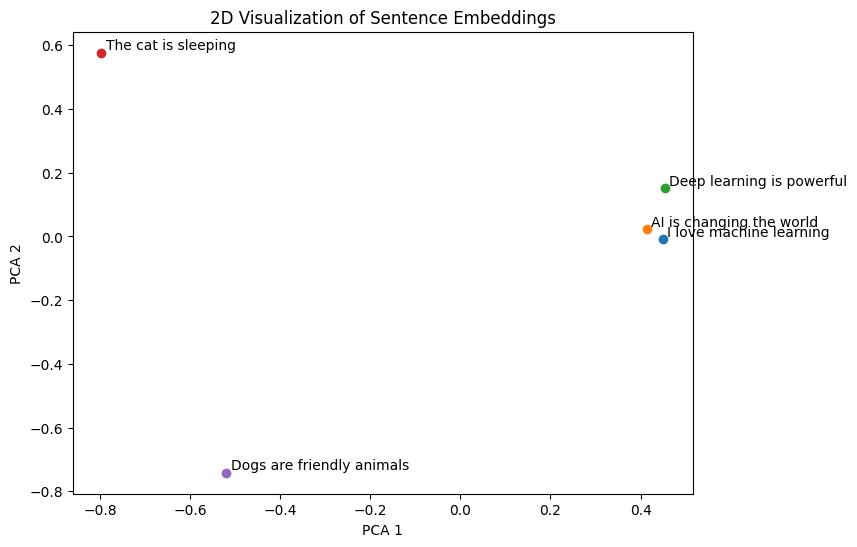

In [ ]:

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

plot_sentences = [
    "I love machine learning",
    "AI is changing the world",
    "Deep learning is powerful",
    "The cat is sleeping",
    "Dogs are friendly animals"
]

plot_embeddings = sentence_model.encode(plot_sentences)

pca = PCA(n_components=2)
reduced = pca.fit_transform(plot_embeddings)

plt.figure(figsize=(8, 6))
for i, sentence in enumerate(plot_sentences):
    plt.scatter(reduced[i, 0], reduced[i, 1])
    plt.text(reduced[i, 0] + 0.01, reduced[i, 1] + 0.01, sentence)

plt.title("2D Visualization of Sentence Embeddings")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()



## 21. Full concept flow

This is the complete flow used in LLM pipelines:

**Input text**  
→ **Tokenizer**  
→ **Tokens**  
→ **Token IDs**  
→ **Embedding layer**  
→ **Vectors**  
→ **Transformer layers**  
→ **Contextual representations**  
→ **Prediction / retrieval / classification**



## 22. Summary

In this notebook, you learned:

- what tokenization is
- why token IDs are needed
- what embeddings are
- how embeddings convert text into vectors
- how to use BERT tokenizer
- how to extract token embeddings
- how to generate sentence embeddings
- how to compare meaning using cosine similarity

These concepts form the foundation of how LLMs process language.



## 23. Practice exercises

### Exercise 1
Tokenize these sentences and print tokens and token IDs:

- `ChatGPT is transforming education.`
- `Embeddings help machines understand meaning.`

### Exercise 2
Try subword tokenization on these words:

- `unbelievable`
- `preprocessing`
- `multilingual`
- `transformational`

### Exercise 3
Generate sentence embeddings for 5 sentences and compare their cosine similarity.

### Exercise 4
Write two sentences using the word **light** with different meanings and discuss contextual embeddings.



## 24. Complete combined script

This cell combines the main parts of the lab in one place.


In [ ]:

from transformers import AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import torch

# Part 1: Tokenization
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
text = "I love learning about large language models."
encoded = tokenizer(text, return_tensors="pt")

tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"][0])
print("Text:", text)
print("Tokens:", tokens)
print("Token IDs:", encoded["input_ids"][0].tolist())
print("Attention Mask:", encoded["attention_mask"][0].tolist())

# Part 2: Subword tokenization
print("\nSubword tokenization examples:")
for word in ["unhappiness", "transformers", "embedding", "tokenization"]:
    print(word, "->", tokenizer.tokenize(word))

# Part 3: Token embeddings
model = AutoModel.from_pretrained("bert-base-uncased")
outputs = model(**encoded)
last_hidden_state = outputs.last_hidden_state

print("\nEmbedding tensor shape:", last_hidden_state.shape)

# Part 4: Sentence embeddings
sentence_model = SentenceTransformer("all-MiniLM-L6-v2")
sentences = [
    "I love machine learning.",
    "I enjoy studying artificial intelligence.",
    "The food is delicious."
]
sentence_embeddings = sentence_model.encode(sentences)

print("\nSentence embeddings shape:", sentence_embeddings.shape)

# Part 5: Similarity
similarity = cosine_similarity(sentence_embeddings)
print("\nCosine similarity matrix:")
print(similarity)


Text: I love learning about large language models.
Tokens: ['[CLS]', 'i', 'love', 'learning', 'about', 'large', 'language', 'models', '.', '[SEP]']
Token IDs: [101, 1045, 2293, 4083, 2055, 2312, 2653, 4275, 1012, 102]
Attention Mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Subword tokenization examples:
unhappiness -> ['un', '##ha', '##pp', '##iness']
transformers -> ['transformers']
embedding -> ['em', '##bed', '##ding']
tokenization -> ['token', '##ization']


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Embedding tensor shape: torch.Size([1, 10, 768])


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Sentence embeddings shape: (3, 384)

Cosine similarity matrix:
[[1.         0.5693294  0.17262046]
 [0.5693294  1.0000001  0.07493301]
 [0.17262046 0.07493301 1.0000002 ]]


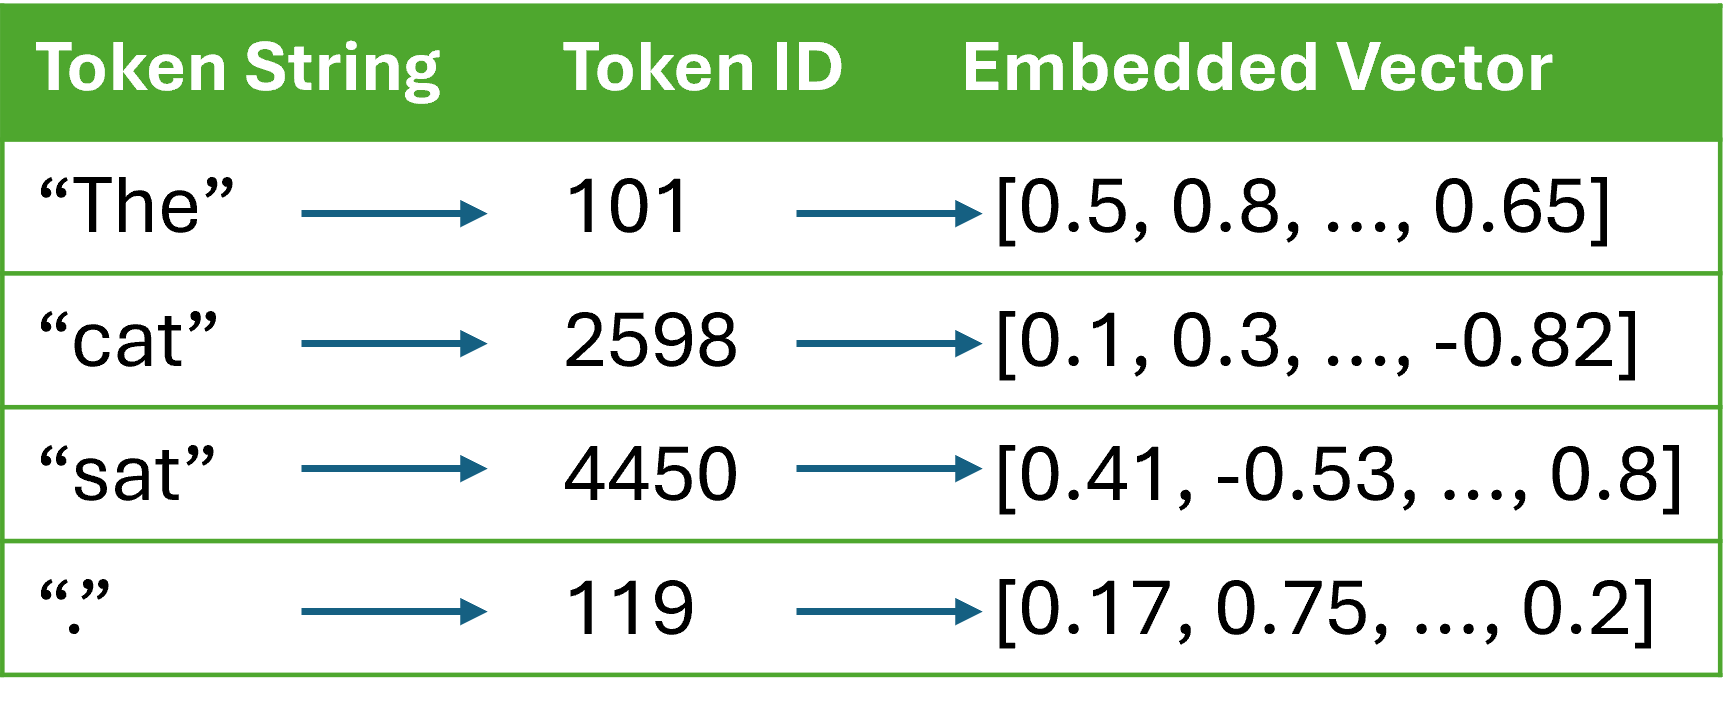

https://medium.com/@chitranshaagarwal/tokenization-in-large-language-models-llms-a-complete-guide-from-beginner-to-advanced-47d0c013c2f4

https://ml-digest.com/architecture-training-of-the-embedding-layer-of-llms/

https://medium.com/@thisiskuhan/tokens-the-currency-of-llms-78b1a5fccd3c

https://medium.com/@thisiskuhan/embeddings-meaning-measured-in-numbers-4a3452df1d1d